# 06 — Score distributions and ROC/DET analysis

This notebook analyzes the saved baseline, resolution, blur, and brightness scores: **ten distinct conditions**, with the original control counted once. No images, crop caches, model weights, or face inference are needed.

**Question:** How does degradation change genuine/impostor score separation across decision thresholds?

The ROC/AUC and interpolated EER results are descriptive summaries of the evaluation scores. They do not select a new deployment threshold or replace the earlier results obtained with thresholds calibrated on the other nine folds. All existing fixed-threshold results are validated and retained.

Inputs are the saved exports from commit `86d331d377d8c665ebe0ec51562704e7890f2aaa`. Local run metadata records the analysis environment independently of the original inference environment. See [the README](../README.md#score-distributions-and-rocdet-analysis) for reproduction instructions.

In [1]:
from pathlib import Path
import sys
import json
from IPython.display import display, Markdown, Image
ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
             if (p / "results/metrics/baseline_scores.csv").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("Open the notebook from within your project repository")
sys.path.insert(0, str(ROOT / "src"))
from score_analysis import run_analysis, sha256
print("Project:", ROOT)
print("Analysis Python:", sys.version.split()[0])

Project: /Users/dhrumil/Fall 2026/Biometrics/Evaluating Face Verification
Analysis Python: 3.13.7


## Validate inputs and run the analysis
Checks cover completed reports, export hashes, baseline provenance, pair membership, labels, exclusions, saved thresholds/decisions, original controls, and the reported fixed-threshold metrics.

The empirical ROC sweep groups equal scores and accepts scores greater than or equal to each threshold. AUC uses the full curve. EER is linearly interpolated where FMR and FNMR cross; it may fall between attainable deterministic operating points. The exported curves retain the reject-all and accept-all endpoints.

In [2]:
report = run_analysis(ROOT)
assert report["status"] == "completed"
for relative, expected in report["output_sha256"].items():
    assert sha256(ROOT / relative) == expected, relative
print(f"\nAnalysis completed in {report['elapsed_seconds']:.2f} seconds")
print("Distinct conditions:", len(report["conditions"]))
print("Model inference performed: none")

Validating saved scores, pair membership, thresholds, and control results ...


Original                 AUC 0.999116 | interpolated EER 0.900%
Resolution 80 × 80       AUC 0.999039 | interpolated EER 0.867%
Resolution 40 × 40       AUC 0.998535 | interpolated EER 1.267%
Resolution 20 × 20       AUC 0.984612 | interpolated EER 6.002%
Blur σ = 1               AUC 0.999051 | interpolated EER 0.834%
Blur σ = 2               AUC 0.998729 | interpolated EER 1.233%
Blur σ = 3               AUC 0.997686 | interpolated EER 1.867%
Brightness × 0.75        AUC 0.999161 | interpolated EER 0.867%
Brightness × 0.50        AUC 0.999098 | interpolated EER 0.867%
Brightness × 0.25        AUC 0.998527 | interpolated EER 1.333%

Analysis completed in 1.16 seconds
Distinct conditions: 10
Model inference performed: none


In [3]:
def curve_table(rows):
    lines = ["| Condition | Pooled AUC | Pooled interpolated EER | Mean fold AUC |",
             "|---|---:|---:|---:|"]
    for r in rows:
        lines.append(f"| {r['label']} | {r['pooled_auc']:.6f} | "
                     f"{100*r['pooled_eer_interpolated']:.3f}% | {r['mean_fold_auc']:.6f} |")
    return "\n".join(lines)
display(Markdown(curve_table(report["conditions"])))
for r in report["conditions"]:
    print(f"{r['label']:24s}: {r['scored_pairs']}/{r['requested_pairs']} pairs; "
          f"fixed-threshold accuracy {100*r['mean_accuracy']:.3f}%, "
          f"FMR {100*r['mean_fmr']:.3f}%, FNMR {100*r['mean_fnmr']:.3f}%")

| Condition | Pooled AUC | Pooled interpolated EER | Mean fold AUC |
|---|---:|---:|---:|
| Original | 0.999116 | 0.900% | 0.999069 |
| Resolution 80 × 80 | 0.999039 | 0.867% | 0.999006 |
| Resolution 40 × 40 | 0.998535 | 1.267% | 0.998471 |
| Resolution 20 × 20 | 0.984612 | 6.002% | 0.984411 |
| Blur σ = 1 | 0.999051 | 0.834% | 0.999026 |
| Blur σ = 2 | 0.998729 | 1.233% | 0.998680 |
| Blur σ = 3 | 0.997686 | 1.867% | 0.997635 |
| Brightness × 0.75 | 0.999161 | 0.867% | 0.999130 |
| Brightness × 0.50 | 0.999098 | 0.867% | 0.999062 |
| Brightness × 0.25 | 0.998527 | 1.333% | 0.998509 |

Original                : 5999/6000 pairs; fixed-threshold accuracy 99.167%, FMR 0.433%, FNMR 1.234%
Resolution 80 × 80      : 5999/6000 pairs; fixed-threshold accuracy 99.117%, FMR 0.433%, FNMR 1.334%
Resolution 40 × 40      : 5999/6000 pairs; fixed-threshold accuracy 98.833%, FMR 0.467%, FNMR 1.867%
Resolution 20 × 20      : 5999/6000 pairs; fixed-threshold accuracy 89.982%, FMR 0.967%, FNMR 19.071%
Blur σ = 1              : 5999/6000 pairs; fixed-threshold accuracy 99.117%, FMR 0.433%, FNMR 1.334%
Blur σ = 2              : 5999/6000 pairs; fixed-threshold accuracy 98.917%, FMR 0.433%, FNMR 1.734%
Blur σ = 3              : 5999/6000 pairs; fixed-threshold accuracy 97.816%, FMR 0.533%, FNMR 3.834%
Brightness × 0.75       : 5999/6000 pairs; fixed-threshold accuracy 99.217%, FMR 0.367%, FNMR 1.200%
Brightness × 0.50       : 5999/6000 pairs; fixed-threshold accuracy 99.200%, FMR 0.333%, FNMR 1.267%
Brightness × 0.25       : 5999/6000 pairs; fixed-threshold accuracy 98.566%, FMR 0.433%, F

## ROC — compare true matches at similar false-match rates
Curves closer to the upper-left indicate better separation in this view. The plot zooms to FMR 0–5% and true match rate 75–100%; the AUC calculation and CSV contain the full curve. A high full-curve AUC can coexist with substantial errors at a particular operating threshold.

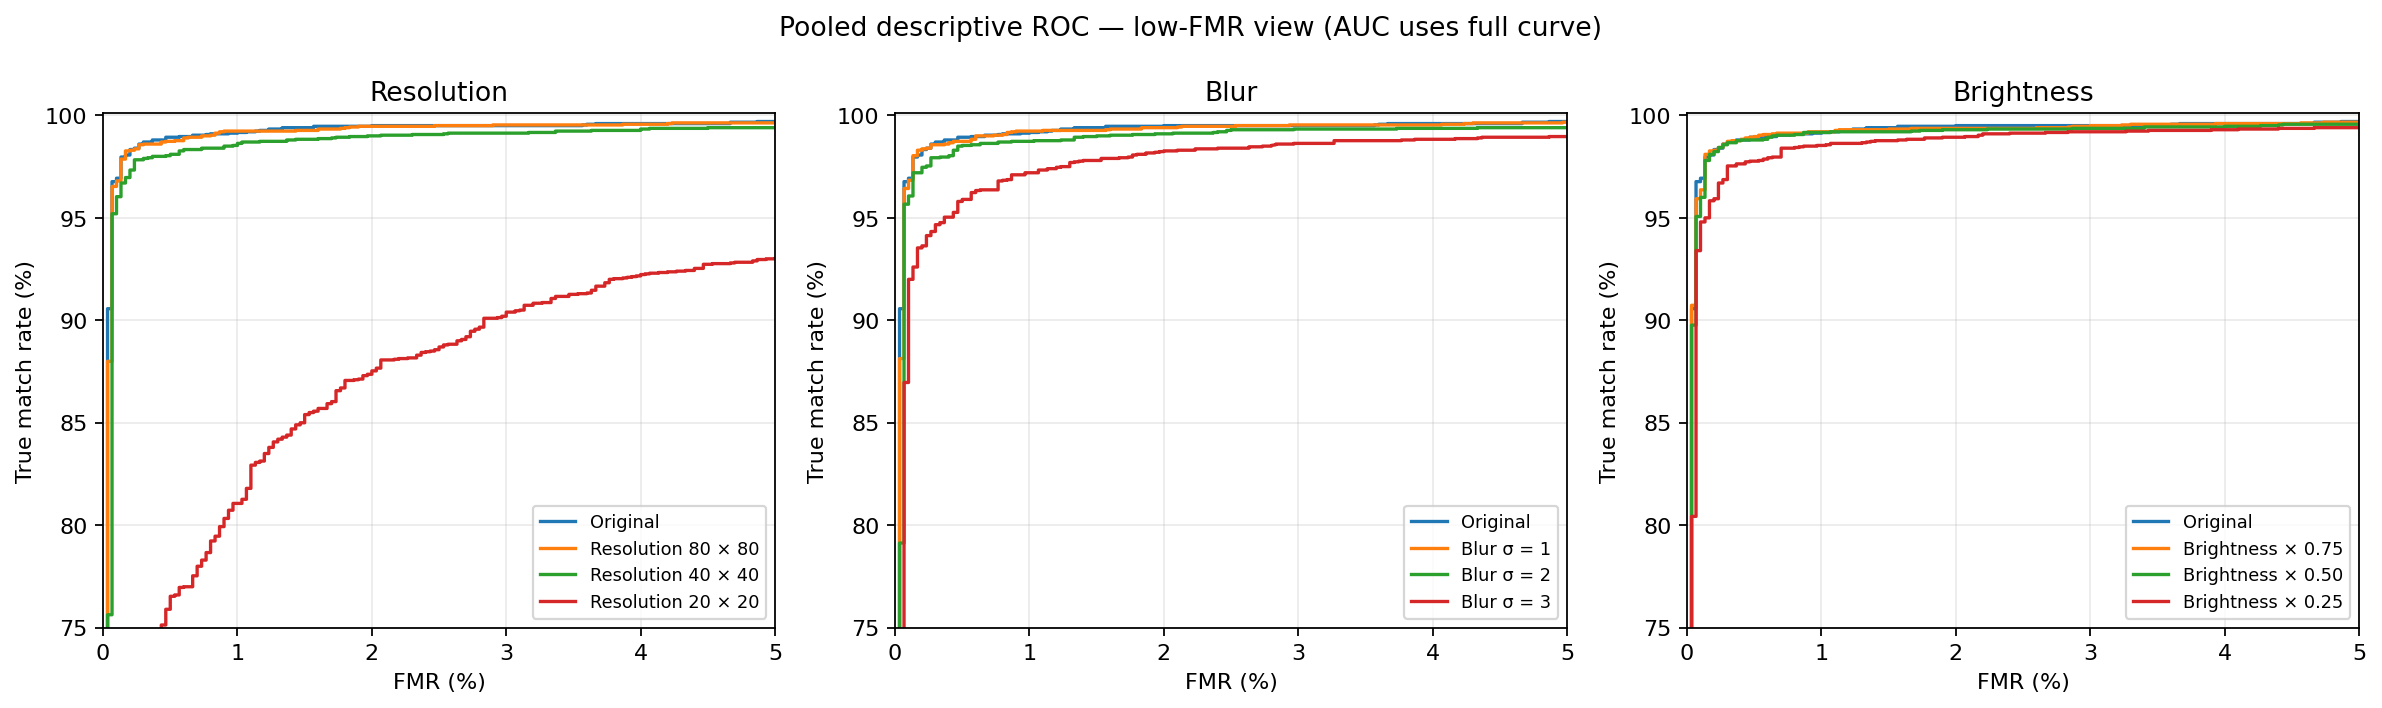

In [4]:
display(Image(filename=str(ROOT / "results/figures/analysis_roc.png")))

## DET — compare the two types of errors
DET uses normal-quantile (probit) axes for FMR and FNMR. Lower and further left indicates fewer errors. True zero/one endpoints cannot be placed on finite probit axes and are omitted only from the display; their empirical values remain in the CSV. Axes are zoomed to 0.01–50%.

There are only 3,000 eligible impostor comparisons in this experiment: one observed false match corresponds to approximately 0.0333% pooled FMR. A plotted tick below that does not establish that such a small error rate is reliably measured. Zero observed errors does not establish zero population risk.

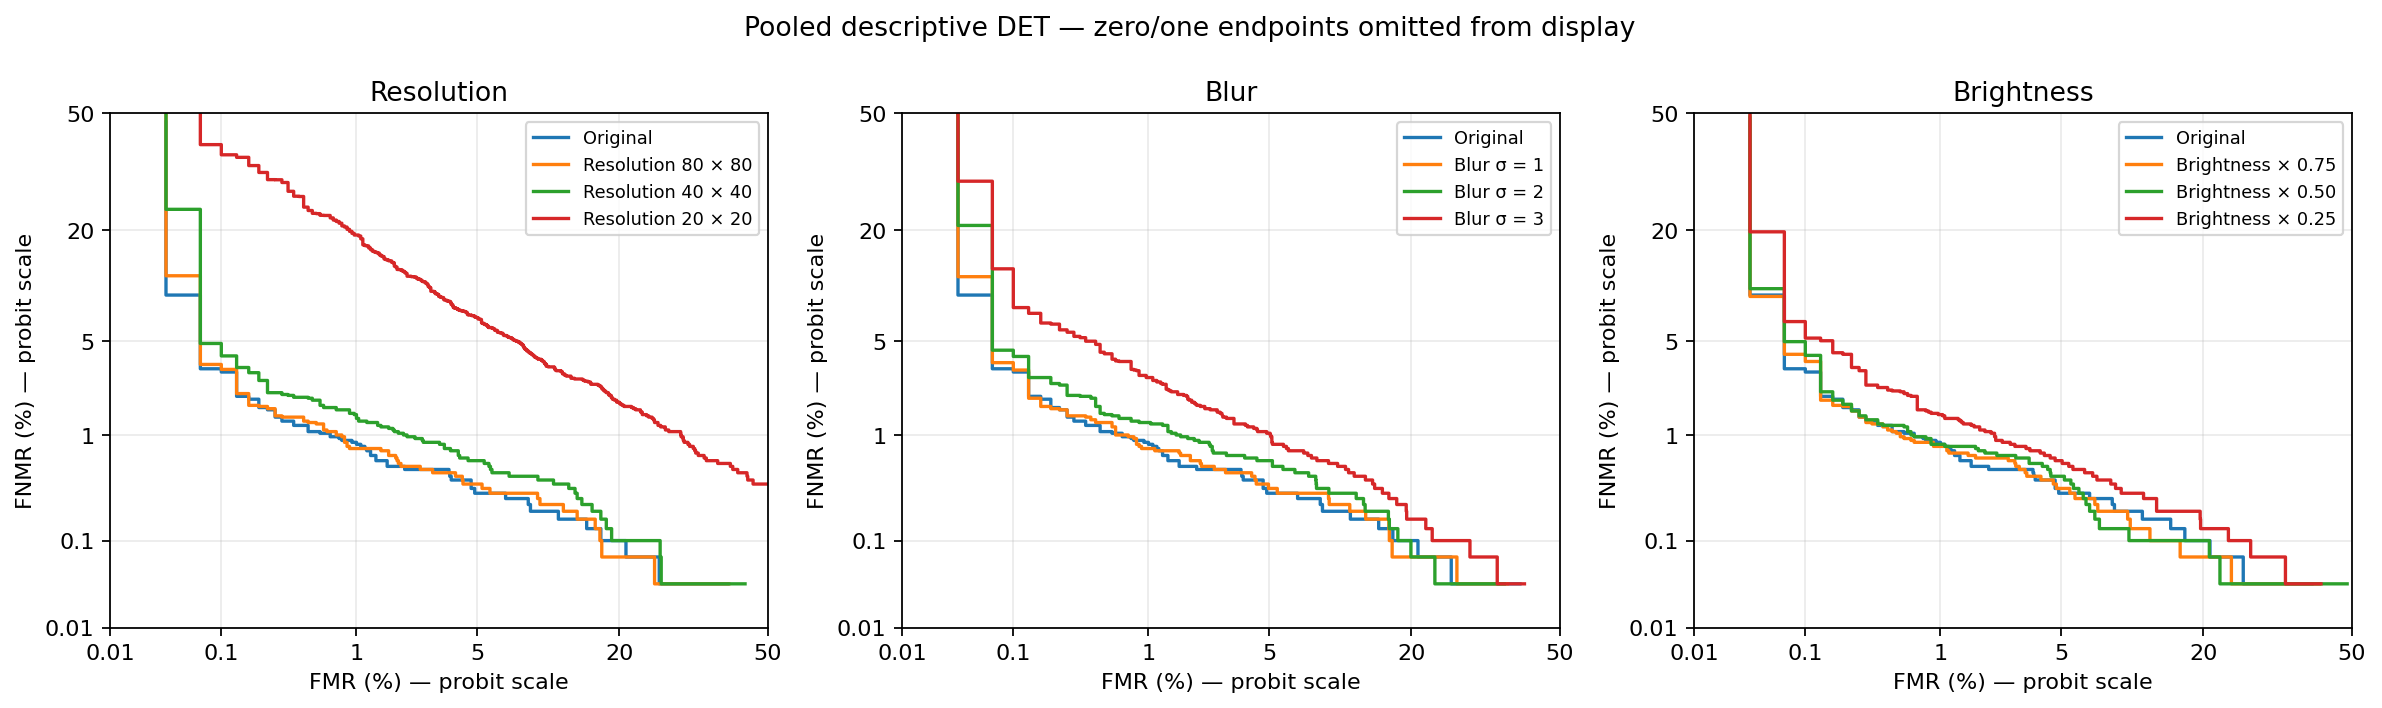

In [5]:
display(Image(filename=str(ROOT / "results/figures/analysis_det.png")))

## Score distributions — inspect genuine and impostor separation
All ten panels use the same bins and axes. Higher cosine similarity favors a match. Look for shifts in genuine scores toward the impostor distribution and greater overlap. Histogram density is normalized separately for each class.

We do not draw a single baseline decision line: the previous evaluation used ten separately calibrated fold thresholds.

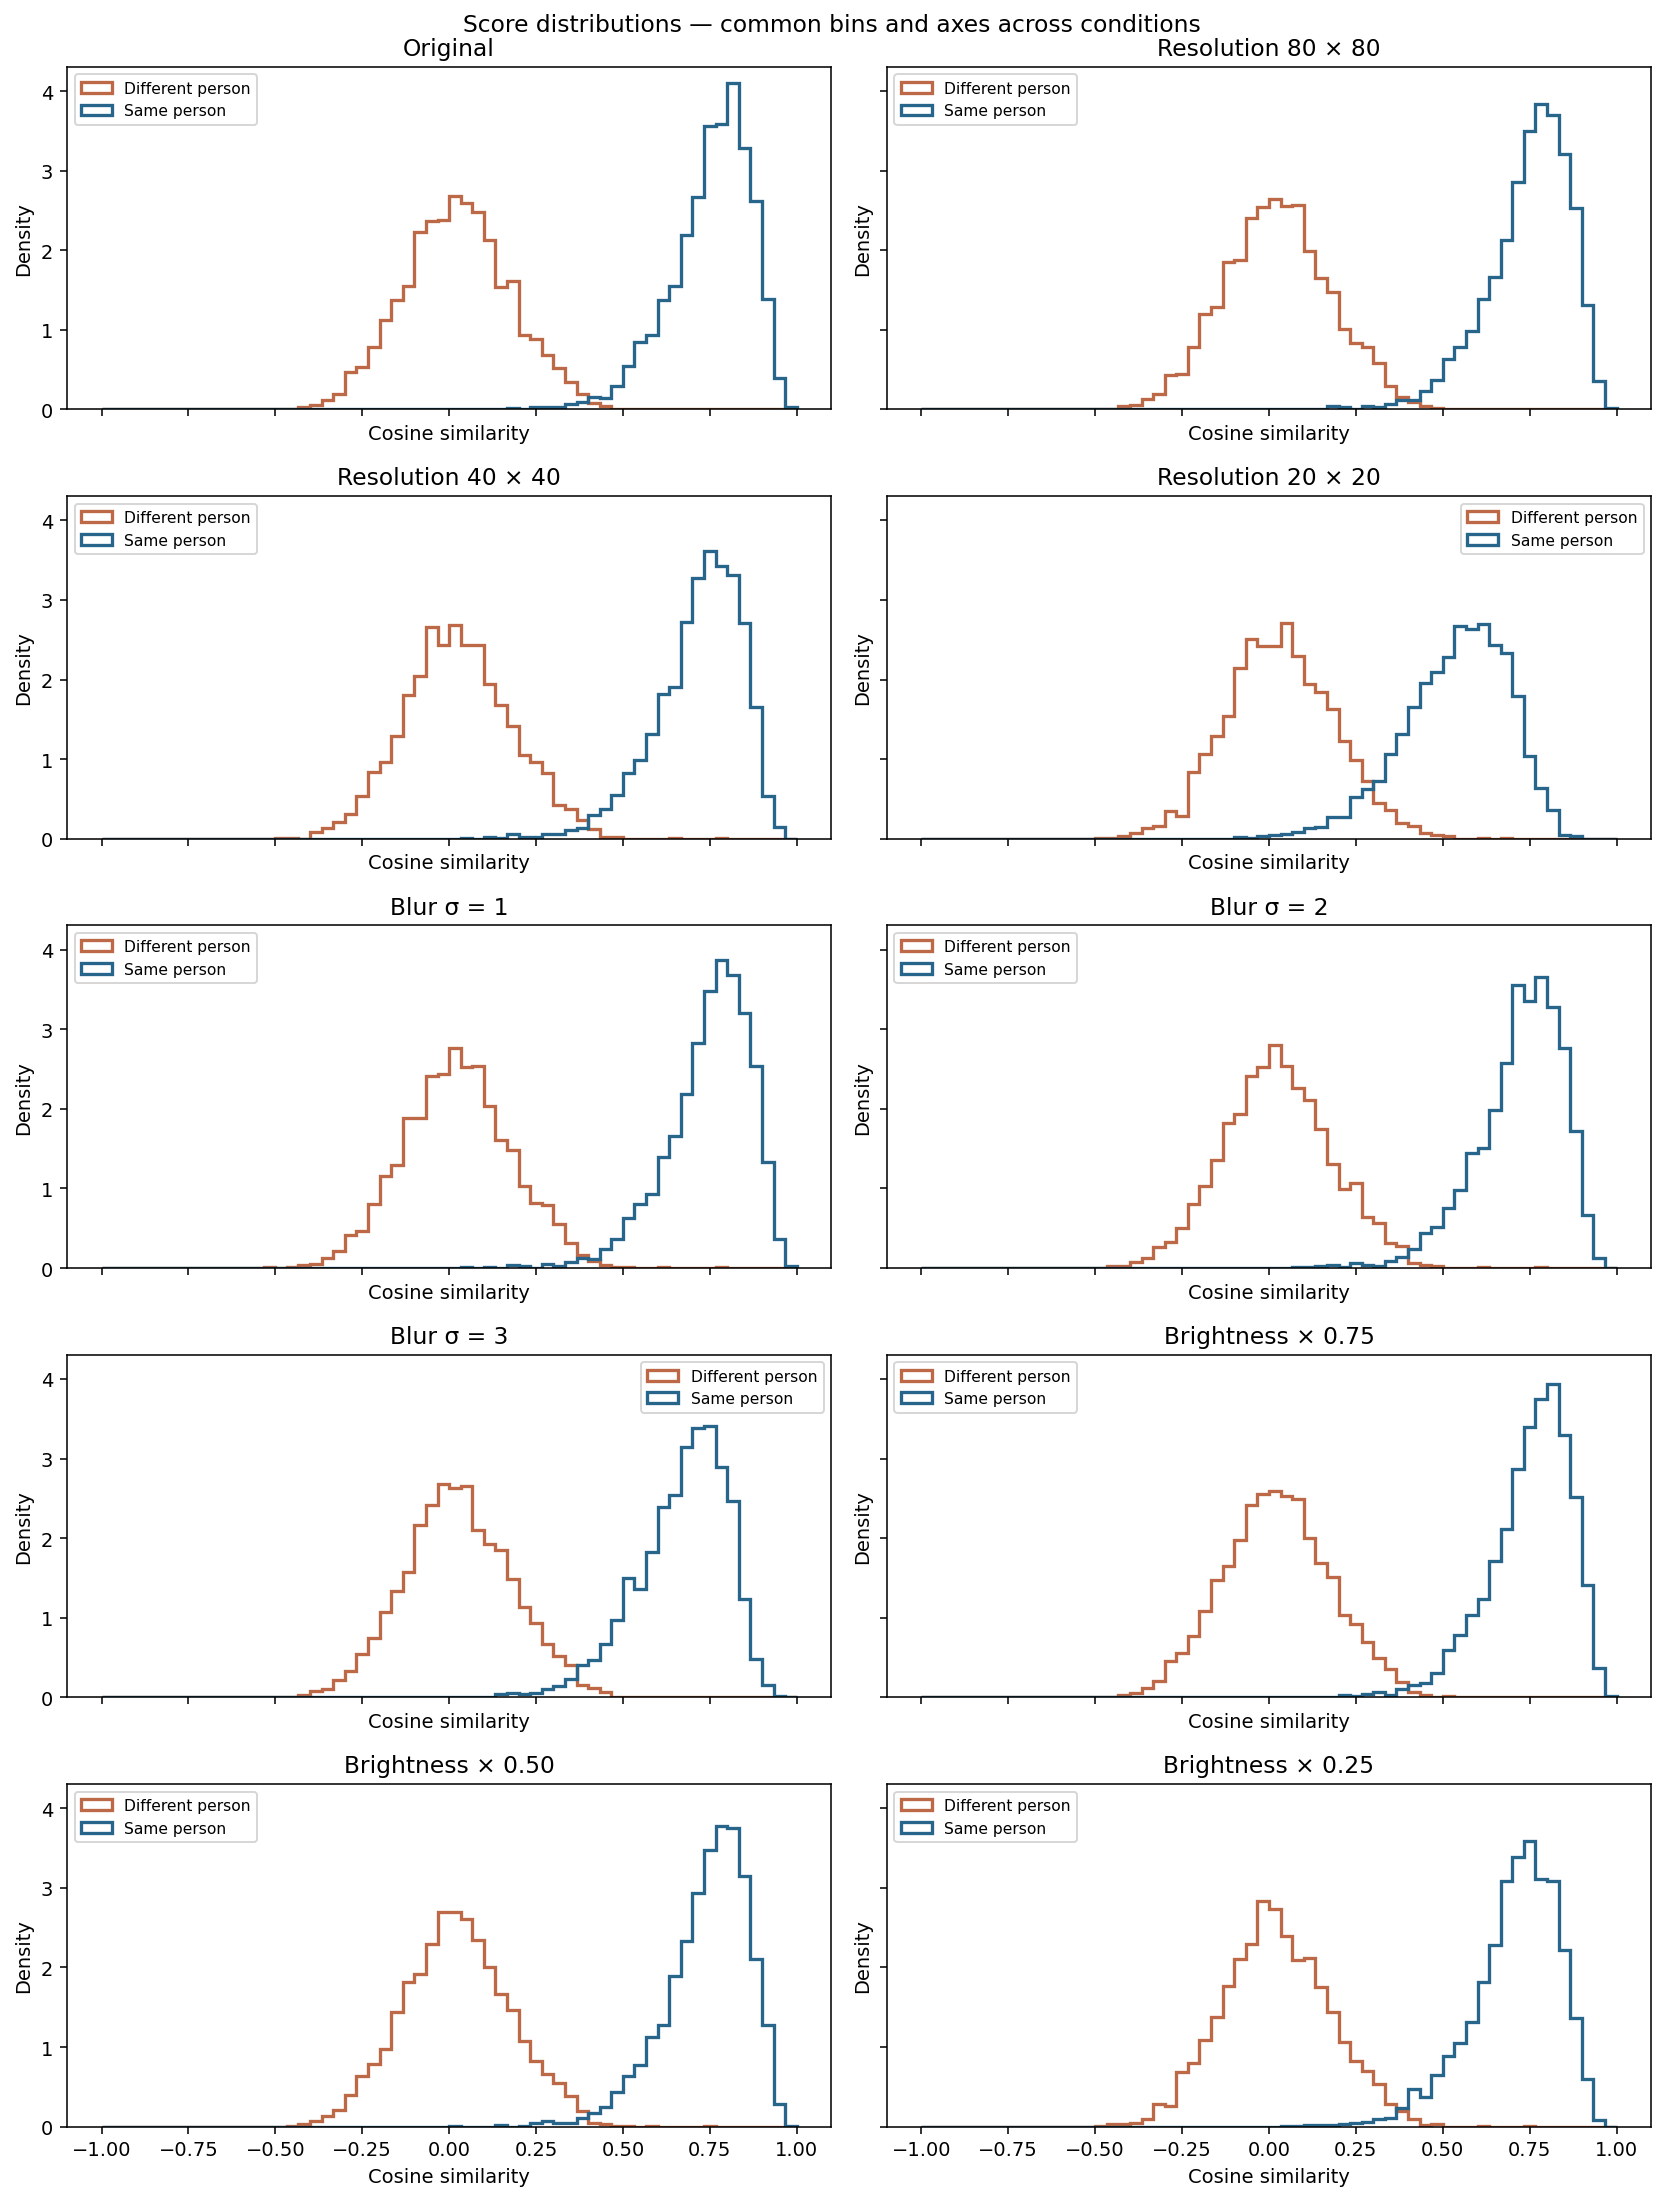

In [6]:
display(Image(filename=str(ROOT / "results/figures/analysis_score_distributions.png")))

In [7]:
lines = ["| Condition | Mean genuine score | Mean impostor score |",
         "|---|---:|---:|"]
for r in report["conditions"]:
    lines.append(f"| {r['label']} | {r['mean_genuine_score']:.4f} | {r['mean_impostor_score']:.4f} |")
display(Markdown("\n".join(lines)))

| Condition | Mean genuine score | Mean impostor score |
|---|---:|---:|
| Original | 0.7515 | 0.0227 |
| Resolution 80 × 80 | 0.7471 | 0.0234 |
| Resolution 40 × 40 | 0.7178 | 0.0255 |
| Resolution 20 × 20 | 0.5364 | 0.0323 |
| Blur σ = 1 | 0.7472 | 0.0234 |
| Blur σ = 2 | 0.7211 | 0.0246 |
| Blur σ = 3 | 0.6691 | 0.0264 |
| Brightness × 0.75 | 0.7497 | 0.0226 |
| Brightness × 0.50 | 0.7411 | 0.0225 |
| Brightness × 0.25 | 0.7060 | 0.0212 |

## Observations from the local run

The local analysis completed on Python 3.13.7 in 1.164 seconds using the
committed scores from Stage 007. All ten conditions retained the same 5,999
eligible pairs (2,999 genuine and 3,000 impostor); the original control was
counted once. No images, model weights, or inference caches were loaded. The
original fixed-threshold results reproduced exactly, including 13 false matches
and 37 false non-matches.

The ROC, DET, and common-bin score-distribution plots were inspected. The
20 × 20 condition has the clearest loss of separation: pooled AUC decreases
from 0.999116 to 0.984612 and interpolated EER rises from 0.900% to 6.002%.
Its genuine-score mean shifts from 0.751540 to 0.536432, while the impostor
mean shifts from 0.022740 to 0.032296. The broader genuine distribution and
its lower-score tail overlap the impostor distribution more visibly. Its
ROC is lower and DET error rates are higher over the displayed low-FMR region.

Blur σ = 3 also shifts genuine scores lower (mean 0.669063), with pooled AUC
0.997686 and EER 1.867%. Brightness × 0.25 has a genuine-score mean of 0.706034,
AUC 0.998527, and EER 1.333%. These results support the earlier fixed-threshold
findings for the tested settings. Resolution, blur, and brightness scales are
not severity-matched, so this is not a universal ordering of degradation types.

Mild changes have small, nonmonotonic differences. Brightness × 0.75 has the
highest pooled AUC here (0.999161); blur σ = 1 has the lowest interpolated EER
(0.834%) despite a slightly lower AUC than the original. AUC averages ranking
performance over the full curve, whereas EER describes its equal-error crossing.
Neither observation establishes a significant benefit. Pooled and mean-fold
metrics are reported separately and need not be equal or rank settings alike.

EER is a descriptive threshold-sweep result, not a newly calibrated operating
point. For example, the 20 × 20 condition still has mean fold accuracy 89.982%,
FMR 0.967%, and FNMR 19.071% at the frozen baseline fold thresholds. Its pooled
EER of 6.002% uses a different evaluation summary and does not replace those
operational rates. The ROC display is zoomed, but AUC uses every curve point;
DET omits zero/one rates only from the plot, retaining them in the CSV.

All 36 regression tests passed, including the nine new analysis tests. An
independent audit checked AUC by genuine–impostor score comparisons, every
one of the 59,990 ROC points by class-specific threshold counts, interpolated
EER, all 100 fold summaries, 20 score-statistic rows, and fixed-threshold
metrics. All four CSVs reproduced the supplied analysis within absolute
floating-point tolerance 1e-12. A separate run with only the helper and seven
saved inputs reproduced all four CSVs and three PNGs byte for byte. Source,
input, and output hashes passed, and all 23 earlier result files were unchanged.
All eight notebook code cells completed without errors. No package changes or
runtime fixes were needed; setup instructions remain in README.md.

**Limitations:** These are descriptive results on already-used evaluation pairs,
with repeated images/identities, dependent folds, and no inferential significance
test. With 3,000 impostor scores, one false match changes pooled FMR by 0.0333
percentage points. Interpolated EER may fall between attainable deterministic
points and does not validate a deployment threshold. Synthetic post-crop
changes and the baseline preprocessing exclusion remain; degraded-input
face detection was not measured. Training-data overlap remains unaudited.
Degradation severity scales are not matched across types.

## Generate the Stage 008 entry
Copy the generated text to `docs/experiment_log.md` and replace the observation placeholder. Add the AUC/EER table and links to the figures to your README, retaining your original fixed-threshold tables. Setup instructions are consolidated in the README.

In [8]:
control = report["conditions"][0]
log_entry = (
    "## Stage 008 — Score distributions and ROC/DET analysis\n\n"
    f"Analysis run (UTC): {report['run_at_utc']}\n\n"
    "### Goal and method\n"
    "Analyze saved cosine similarities for ten conditions without rerunning the face model. "
    "Validate input hashes, common pair membership, labels, exclusions, controls, and fixed "
    "baseline threshold decisions. Compute pooled and per-fold ROC AUC and linearly "
    "interpolated EER; plot descriptive pooled ROC/DET curves and score distributions.\n\n"
    "### Results\n\n" + curve_table(report["conditions"]) + "\n\n"
    f"Every condition uses {control['scored_pairs']}/{control['requested_pairs']} pairs "
    f"({control['genuine_pairs']} genuine and {control['impostor_pairs']} impostor). "
    "Existing fixed-threshold metrics were reproduced and preserved.\n\n"
    "### Observations\n[Replace with your interpretation of the measured curves and score distributions.]\n\n"
    "### Limitations\n"
    "Pooled AUC/EER are descriptive evaluation summaries, not new validated operating thresholds. "
    "Interpolated EER may lie between attainable deterministic points. Finite pair counts limit "
    "low-FMR precision, and fold dependence prevents treating fold spread as an independent "
    "significance test. Earlier synthetic-degradation and exclusion limitations remain.\n\n"
    "### Next step\n"
    "Consolidate reproduction instructions, findings, and limitations; verify the final repository "
    "and submission archive including Git history.\n"
)
print(log_entry)

## Stage 008 — Score distributions and ROC/DET analysis

Analysis run (UTC): 2026-09-11T17:29:28.739298+00:00

### Goal and method
Analyze saved cosine similarities for ten conditions without rerunning the face model. Validate input hashes, common pair membership, labels, exclusions, controls, and fixed baseline threshold decisions. Compute pooled and per-fold ROC AUC and linearly interpolated EER; plot descriptive pooled ROC/DET curves and score distributions.

### Results

| Condition | Pooled AUC | Pooled interpolated EER | Mean fold AUC |
|---|---:|---:|---:|
| Original | 0.999116 | 0.900% | 0.999069 |
| Resolution 80 × 80 | 0.999039 | 0.867% | 0.999006 |
| Resolution 40 × 40 | 0.998535 | 1.267% | 0.998471 |
| Resolution 20 × 20 | 0.984612 | 6.002% | 0.984411 |
| Blur σ = 1 | 0.999051 | 0.834% | 0.999026 |
| Blur σ = 2 | 0.998729 | 1.233% | 0.998680 |
| Blur σ = 3 | 0.997686 | 1.867% | 0.997635 |
| Brightness × 0.75 | 0.999161 | 0.867% | 0.999130 |
| Brightness × 0.50 | 0.999098 | 

## Method references
- [ROC curve definitions and threshold convention](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.roc_curve.html)
- [DET curves and normal-deviate axes](https://scikit-learn.org/stable/auto_examples/model_selection/plot_det.html)

Implementation uses NumPy, Matplotlib, and Python's standard library. Scikit-learn is a reference, not a required dependency.